In [1]:
import pandas as pd


In [2]:
import numpy as np

In [3]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [4]:
import matplotlib.pyplot as plt

In [5]:
from sklearn.preprocessing import MinMaxScaler

In [6]:
df_penultimate = pd.read_csv(r"C:\Users\USER\Downloads\processed_sales_data (1).csv")

In [7]:
print(df_penultimate.columns)

Index(['Unnamed: 0', 'date', 'analytic_business_unit',
       'analytic_super_category', 'analytic_category', 'analytic_vertical',
       'cms_vertical', 'price_bucket', 'orders', 'units', 'gmv', 'month',
       'year', 'orders_lag_1', 'units_lag_1', 'gmv_lag_1', 'orders_ma_3',
       'units_ma_3', 'gmv_ma_3'],
      dtype='object')


In [8]:
df_penultimate.drop(['Unnamed: 0', 'orders_ma_3',
       'units_ma_3', 'gmv_ma_3'], axis=1, inplace=True)

In [9]:
print(df_penultimate.head(5))

         date analytic_business_unit analytic_super_category  \
0  2020-02-01                   Home     HomeImprovementTool   
1  2020-02-01                   Home     HomeImprovementTool   
2  2020-02-01                   Home     HomeImprovementTool   
3  2020-02-01                   Home     HomeImprovementTool   
4  2020-02-01                   Home     HomeImprovementTool   

     analytic_category analytic_vertical    cms_vertical price_bucket  orders  \
0       HomeAndUtility     ApplianceKnob  appliance_knob        0-300   169.0   
1  FittingsAndFixtures         WaterPump      water_pump      300-500  1118.0   
2  FittingsAndFixtures         WaterPump      water_pump         500+  1627.0   
3  FittingsAndFixtures         WoodBlock      wood_block        0-300    11.0   
4  FittingsAndFixtures         WoodStain      wood_stain        0-300    15.0   

    units        gmv  month  year  orders_lag_1  units_lag_1  gmv_lag_1  
0   179.0    39656.0      2  2020         166.0       

In [10]:
# Create Moving Average Features (3-month rolling average)
df_penultimate['orders_ma_3'] = df_penultimate.groupby(['analytic_business_unit', 'analytic_super_category', 
                                                      'analytic_category', 'analytic_vertical', 'cms_vertical', 
                                                      'price_bucket'])['orders'].transform(lambda x:x.shift(1).rolling(3, min_periods=1).mean())

df_penultimate['units_ma_3'] = df_penultimate.groupby(['analytic_business_unit', 'analytic_super_category', 
                                                     'analytic_category', 'analytic_vertical', 'cms_vertical', 
                                                     'price_bucket'])['units'].transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())

df_penultimate['gmv_ma_3'] = df_penultimate.groupby(['analytic_business_unit', 'analytic_super_category', 
                                                   'analytic_category', 'analytic_vertical', 'cms_vertical', 
                                                   'price_bucket'])['gmv'].transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())

In [11]:
feature_cols = [
    'orders_lag_1', 'units_lag_1', 'gmv_lag_1',
    'orders_ma_3', 'units_ma_3', 'gmv_ma_3'
]

df_penultimate = df_penultimate.dropna(subset=feature_cols).reset_index(drop=True)

In [12]:
print(df_penultimate.head())

         date analytic_business_unit analytic_super_category  \
0  2020-03-01                   Home     HomeImprovementTool   
1  2020-03-01                   Home     HomeImprovementTool   
2  2020-03-01                   Home     HomeImprovementTool   
3  2020-03-01                   Home     HomeImprovementTool   
4  2020-03-01                   Home     HomeImprovementTool   

  analytic_category analytic_vertical       cms_vertical price_bucket  orders  \
0    HomeAndUtility           CashBox           cash_box         500+   234.0   
1    HomeAndUtility         ClothClip         cloth_clip      300-500   317.0   
2    HomeAndUtility   BabySafetyLocks  child_safety_lock         500+     7.0   
3    HomeAndUtility   BucketSeatCover       bucket_cover        0-300    20.0   
4    HomeAndUtility        BungeeCord        bungee_cord        0-300    12.0   

   units       gmv  month  year  orders_lag_1  units_lag_1  gmv_lag_1  \
0  237.0  225631.0      3  2020         356.0        36

In [13]:
df_penultimate.to_csv("C:/Users/USER/Downloads/final_sales_data.csv", index=False)

In [14]:
df=pd.read_csv("C:/Users/USER/Downloads/final_sales_data.csv")


In [15]:
df.head()

,date,analytic_business_unit,analytic_super_category,analytic_category,analytic_vertical,cms_vertical,price_bucket,orders,units,gmv,month,year,orders_lag_1,units_lag_1,gmv_lag_1,orders_ma_3,units_ma_3,gmv_ma_3
0,2020-03-01,Home,HomeImprovementTool,HomeAndUtility,CashBox,cash_box,500+,234.0,237.0,225631.0,3,2020,356.0,369.0,318303.0,356.0,369.0,318303.0
1,2020-03-01,Home,HomeImprovementTool,HomeAndUtility,ClothClip,cloth_clip,300-500,317.0,320.0,118665.0,3,2020,394.0,409.0,156898.0,394.0,409.0,156898.0
2,2020-03-01,Home,HomeImprovementTool,HomeAndUtility,BabySafetyLocks,child_safety_lock,500+,7.0,7.0,5352.0,3,2020,2.0,2.0,1588.0,2.0,2.0,1588.0
3,2020-03-01,Home,HomeImprovementTool,HomeAndUtility,BucketSeatCover,bucket_cover,0-300,20.0,20.0,4740.0,3,2020,36.0,36.0,7845.0,36.0,36.0,7845.0
4,2020-03-01,Home,HomeImprovementTool,HomeAndUtility,BungeeCord,bungee_cord,0-300,12.0,14.0,3480.0,3,2020,11.0,14.0,2692.0,11.0,14.0,2692.0


In [16]:
df['date'] = pd.to_datetime(df['date'])

In [17]:
df.describe()

,date,orders,units,gmv,month,year,orders_lag_1,units_lag_1,gmv_lag_1,orders_ma_3,units_ma_3,gmv_ma_3
count,570427,5.704270e+05,5.704270e+05,5.704270e+05,570427.000000,570427.000000,5.704270e+05,5.704270e+05,5.704270e+05,5.704270e+05,5.704270e+05,5.704270e+05
mean,2022-08-06 18:32:57.192524288,8.320326e+03,8.895281e+03,1.064159e+07,6.526001,2022.138032,8.133182e+03,8.688493e+03,1.031405e+07,7.979028e+03,8.517677e+03,1.004567e+07
min,2020-03-01 00:00:00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000,2020.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
25%,2021-07-01 00:00:00,2.100000e+01,2.300000e+01,1.116500e+04,4.000000,2021.000000,2.100000e+01,2.200000e+01,1.081900e+04,2.166667e+01,2.300000e+01,1.158217e+04
50%,2022-09-01 00:00:00,2.430000e+02,2.570000e+02,1.257900e+05,7.000000,2022.000000,2.360000e+02,2.500000e+02,1.224680e+05,2.410000e+02,2.543333e+02,1.247187e+05
75%,2023-09-01 00:00:00,2.405000e+03,2.521000e+03,1.187482e+06,9.000000,2023.000000,2.351000e+03,2.460000e+03,1.160016e+06,2.370000e+03,2.480167e+03,1.164270e+06
max,2024-10-01 00:00:00,7.553127e+06,7.755222e+06,1.592835e+11,12.000000,2024.000000,7.553127e+06,7.755222e+06,1.592835e+11,4.426326e+06,4.610769e+06,8.597613e+10
std,NaN,5.538343e+04,5.859241e+04,5.304909e+08,3.309937,1.313045,5.415840e+04,5.727155e+04,5.100034e+08,5.132688e+04,5.411609e+04,4.538283e+08


In [18]:
df['date'].is_monotonic_increasing #To check if date is in ascending order, since the next step involves splitting training and testing data in chronological order to ensure there is no data leakage

True

In [19]:
cutoff_date = '2024-01-01'

train = df[df['date'] < cutoff_date]
test = df[df['date'] >= cutoff_date]

In [20]:
features = [
    'orders_lag_1',
    'units_lag_1',
    'gmv_lag_1',
    'orders_ma_3',
    'units_ma_3',
    'gmv_ma_3'
]

X_train = train[features]
y_train = train['orders']

X_test = test[features]
y_test = test['orders']

In [21]:
#EXPLORATORY DATA ANALYSIS

In [22]:
# 1. Data Quality Check
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values: 0
Duplicate rows: 0


In [23]:
# 2. Target Variable  distribution
ordmean=df['orders'].mean()
ordmedian=df['orders'].median()

print(ordmean,"\n",ordmedian)

8320.3264028526 
 243.0


In [24]:
print("Target Skewness:", df['orders'].skew())
print("Target Kurtosis:", df['orders'].kurt())

Target Skewness: 38.19914714609977
Target Kurtosis: 2924.2180734282656


In [25]:
# 3. Trend Visualization
monthly_orders = (
    df.groupby('date')['orders']
      .sum()
      .reset_index()
)

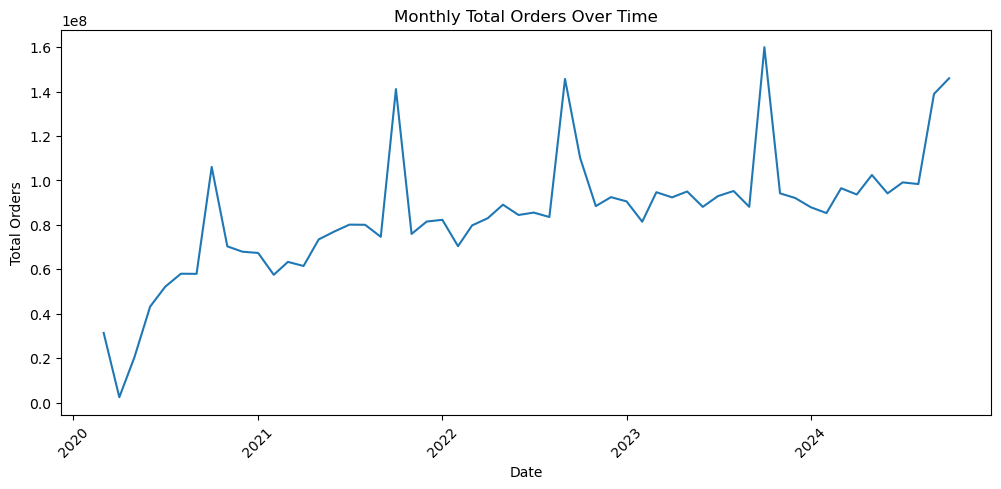

In [26]:
plt.figure(figsize=(12,5))

plt.plot(monthly_orders['date'], monthly_orders['orders'])

plt.xlabel('Date')
plt.ylabel('Total Orders')
plt.title('Monthly Total Orders Over Time')

plt.xticks(rotation=45)
plt.show()

In [27]:
#MODEL TRAINING

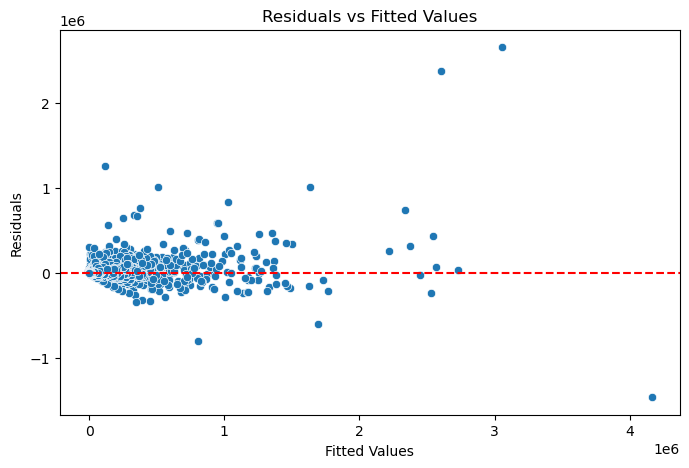

Breusch-Pagan Test
LM Statistic: 12896.735676292954
p-value: 0.0
Conclusion: Reject H0 → Evidence of heteroscedasticity.


In [28]:
##LINEAR REGRESSION

# 1. Naive Baseline Model using raw features

from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
# Predict on test set
lr_preds = lr_model.predict(X_test)

import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm

# Calculation and visualisation of residuals
residuals = y_test - lr_preds

# -----------------------------
# 1. Residuals vs Fitted Values
# -----------------------------
plt.figure(figsize=(8, 5))
sns.scatterplot(x=lr_preds, y=residuals)

plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()


# -----------------------------
# 2. Breusch-Pagan Test
# -----------------------------

# Add constant to fitted values
X_bp = sm.add_constant(lr_preds)

bp_test = het_breuschpagan(residuals, X_bp)

bp_stat = bp_test[0]
bp_pvalue = bp_test[1]

print("Breusch-Pagan Test")
print("LM Statistic:", bp_stat)
print("p-value:", bp_pvalue)

if bp_pvalue > 0.05:
    print("Conclusion: Fail to reject H0 → Homoscedasticity is likely.")
else:
    print("Conclusion: Reject H0 → Evidence of heteroscedasticity.")

In [29]:
lrrmse = np.sqrt(
    mean_squared_error(y_test, lr_preds)
)

lrmae = mean_absolute_error(
    y_test, lr_preds
)

lrr2 = r2_score(
    y_test, lr_preds
)

lrmape = np.mean(
    np.abs((y_test - lr_preds) / y_test)
) * 100

print("Linear Regression Results")
print("--------------------------------")
print(f"RMSE : {lrrmse:.2f}")
print(f"MAE  : {lrmae:.2f}")
print(f"R²   : {lrr2:.2f}")
print(f"MAPE : {lrmape:.2f}%")

Linear Regression Results
--------------------------------
RMSE : 19282.33
MAE  : 2489.93
R²   : 0.90
MAPE : 3748.97%


In [30]:
##Checking for multicollinearity among features

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select only the features
X = df[features].dropna()

# Calculate VIF
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif_data)

        Feature         VIF
0  orders_lag_1  726.442267
1   units_lag_1  637.256143
2     gmv_lag_1   13.334909
3   orders_ma_3  821.344752
4    units_ma_3  733.806100
5      gmv_ma_3   13.090181


In [31]:
correlation_matrix = X.corr()

print(correlation_matrix)

              orders_lag_1  units_lag_1  gmv_lag_1  orders_ma_3  units_ma_3  \
orders_lag_1      1.000000     0.995740   0.624824     0.960855    0.957194   
units_lag_1       0.995740     1.000000   0.616994     0.954718    0.958110   
gmv_lag_1         0.624824     0.616994   1.000000     0.574167    0.568411   
orders_ma_3       0.960855     0.954718   0.574167     1.000000    0.996347   
units_ma_3        0.957194     0.958110   0.568411     0.996347    1.000000   
gmv_ma_3          0.601416     0.593662   0.922972     0.626355    0.620445   

              gmv_ma_3  
orders_lag_1  0.601416  
units_lag_1   0.593662  
gmv_lag_1     0.922972  
orders_ma_3   0.626355  
units_ma_3    0.620445  
gmv_ma_3      1.000000  


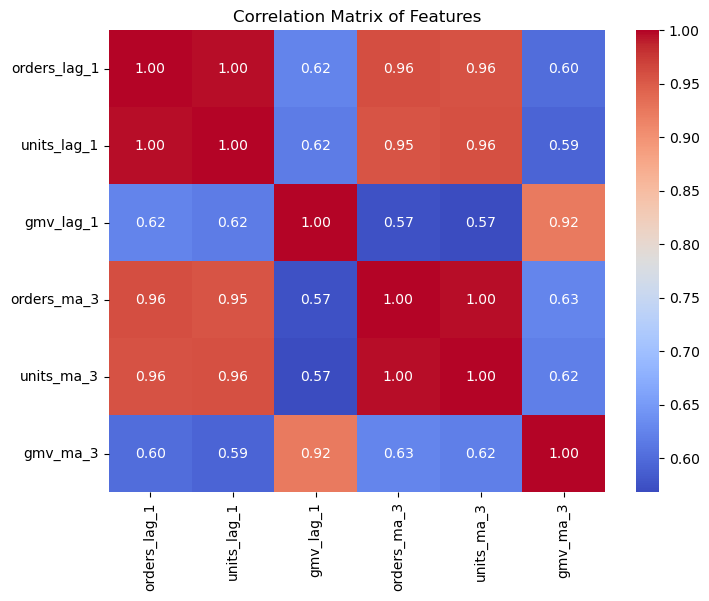

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of Features')
plt.show()

In [33]:
# Strong Multicollinearity is detected among predictor variables. Scaling and PCA needs to be done to improve model performance.

In [34]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [35]:
# Scale features
# Fit ONLY on training data
# -----------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# -----------------------------
#  Apply PCA
# Fit ONLY on training data
# -----------------------------

pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

pca_df = pd.DataFrame(
    X_train_pca,
    columns=['PC1', 'PC2']
).reset_index(drop=True)


print(pca_df.head())
# Print explained variance ratio
print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

# Print total variance explained
total_variance_explained = pca.explained_variance_ratio_.sum()

print("\nTotal Variance Explained:")
print(total_variance_explained)
print(f"{total_variance_explained * 100:.2f}%")


        PC1       PC2
0 -0.261673  0.119378
1 -0.260661  0.118214
2 -0.273832  0.125352
3 -0.272721  0.124726
4 -0.273491  0.125157

Explained Variance Ratio:
[0.82161739 0.14966603]

Total Variance Explained:
0.9712834204562653
97.13%


In [36]:
# Train Linear Regression
lr_pca = LinearRegression()
lr_pca.fit(X_train_pca, y_train)

#  Predict on test data
y_pred_pca = lr_pca.predict(X_test_pca)

#  Evaluate
lr_rmse_pca = np.sqrt(
    mean_squared_error(y_test, y_pred_pca)
)

lr_mae_pca = mean_absolute_error(
    y_test, y_pred_pca
)

lr_r2_pca = r2_score(
    y_test, y_pred_pca
)

lr_mape_pca = np.mean(
    np.abs((y_test - y_pred_pca) / y_test)
) * 100


print("PCA Linear Regression Results")
print("--------------------------------")
print("RMSE :", lr_rmse_pca)
print("MAE  :", lr_mae_pca)
print("R²   :", lr_r2_pca)
print("MAPE :", lr_mape_pca, "%")

PCA Linear Regression Results
--------------------------------
RMSE : 18258.787710622055
MAE  : 2364.247419429616
R²   : 0.9110933008800894
MAPE : 3568.2987705865044 %


In [37]:
# RMSE results of Linear Regression with raw features is higher than that with PCA.R-squared value has also improved
# Linear Regression with PCA is a better model

In [38]:
# L2 Regularization was also explored to deal with multicollinearity and overfiiting

In [39]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# -----------------------------
# 1. Scale the features
# -----------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# -----------------------------
# 2. Train Ridge Regression
# -----------------------------
alphas = [0.01, 0.1, 1, 10, 100, 1000]

for alpha in alphas:

    ridge_model = Ridge(alpha=alpha)

    ridge_model.fit(X_train_scaled, y_train)

    ridge_preds = ridge_model.predict(X_test_scaled)

    rmse = np.sqrt(mean_squared_error(y_test, ridge_preds))
    mae = mean_absolute_error(y_test, ridge_preds)
    r2 = r2_score(y_test, ridge_preds)

    mape = np.mean(
        np.abs((y_test - ridge_preds) / y_test)
    ) * 100

    print(f"\nAlpha = {alpha}")
    print(f"RMSE : {rmse:.2f}")
    print(f"MAE  : {mae:.2f}")
    print(f"R²   : {r2:.2f}")
    print(f"MAPE : {mape:.2f}%")


Alpha = 0.01
RMSE : 19282.32
MAE  : 2489.93
R²   : 0.90
MAPE : 3748.97%

Alpha = 0.1
RMSE : 19282.30
MAE  : 2489.92
R²   : 0.90
MAPE : 3748.96%

Alpha = 1
RMSE : 19282.11
MAE  : 2489.85
R²   : 0.90
MAPE : 3748.89%

Alpha = 10
RMSE : 19280.20
MAE  : 2489.12
R²   : 0.90
MAPE : 3748.23%

Alpha = 100
RMSE : 19262.69
MAE  : 2482.26
R²   : 0.90
MAPE : 3742.12%

Alpha = 1000
RMSE : 19177.83
MAE  : 2443.19
R²   : 0.90
MAPE : 3714.43%


In [40]:
#Results remain largely unchanged regardless of the regularization parameter (alpha) value, indicating that the model has not overfitted.

In [41]:
##LSTM

!pip install tensorflow

In [42]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [43]:
# Orders are grouped per category sequence instead of individual date-wise records, to make more meaningful predictions 
# LSTM's ability to remember information across multiple time steps utilised 

In [44]:
# Convert date
df['date'] = pd.to_datetime(df['date'])

# Create series ID
series_cols = [
    'analytic_business_unit',
    'analytic_super_category',
    'analytic_category',
    'analytic_vertical',
    'cms_vertical',
    'price_bucket'
]

df['series_id'] = df[series_cols].astype(str).agg('_'.join, axis=1)

# Sort
df = df.sort_values(['series_id', 'date']).reset_index(drop=True)

# Train-test split
cutoff_date = '2024-01-01'

train = df[df['date'] < cutoff_date].copy()
test = df[df['date'] >= cutoff_date].copy()

In [45]:
features = ['orders', 'month', 'year']
target = 'orders'

In [46]:
X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_scaler.fit(train[features])
y_scaler.fit(train[['orders']])

train_scaled = train.copy()
test_scaled = test.copy()

train_scaled[features] = X_scaler.transform(
    train[features]
)

test_scaled[features] = X_scaler.transform(
    test[features]
)

train_scaled['orders_scaled'] = y_scaler.transform(
    train[['orders']]
)

test_scaled['orders_scaled'] = y_scaler.transform(
    test[['orders']]
)

In [47]:
window = 3

def create_sequences(data):
    
    X = []
    y = []
    
    for series_id, group in data.groupby('series_id'):
        
        group = group.sort_values('date')
        
        feature_values = group[features].values
        target_values = group['orders_scaled'].values
        
        for i in range(window, len(group)):
            
            X.append(feature_values[i-window:i])
            y.append(target_values[i])
    
    return np.array(X), np.array(y)

In [48]:
X_train, y_train = create_sequences(train_scaled)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (420924, 3, 3)
y_train shape: (420924,)


In [49]:
combined = pd.concat(
    [train_scaled, test_scaled]
).sort_values(
    ['series_id', 'date']
).reset_index(drop=True)

In [50]:
def create_test_sequences(data, test_start):
    
    X = []
    y = []
    
    for series_id, group in data.groupby('series_id'):
        
        group = group.sort_values('date').reset_index(drop=True)
        
        for i in range(window, len(group)):
            
            target_date = group.loc[i, 'date']
            
            if target_date >= test_start:
                
                X.append(
                    group.loc[
                        i-window:i-1, features
                    ].values
                )
                
                y.append(
                    group.loc[i, 'orders_scaled']
                )
    
    return np.array(X), np.array(y)

In [51]:
X_test, y_test = create_test_sequences(
    combined,
    pd.Timestamp('2024-01-01')
)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (104044, 3, 3)
y_test shape: (104044,)


In [52]:
model = Sequential([
    LSTM(
        32,
        input_shape=(window, len(features))
    ),
    
    Dropout(0.2),
    
    Dense(16, activation='relu'),
    
    Dense(1)
])

C:\Users\USER\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [53]:
model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 32)                  │           4,608 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,153 (20.13 KB)

 Trainable params: 5,153 (20.13 KB)

 Non-trainable params: 0 (0.00 B)

In [54]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    shuffle=False,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
11839/11839 ━━━━━━━━━━━━━━━━━━━━ 29s 2ms/step - loss: 3.4066e-05 - val_loss: 2.9724e-04
Epoch 2/100
11839/11839 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step - loss: 3.1046e-05 - val_loss: 2.8841e-04
Epoch 3/100
11839/11839 ━━━━━━━━━━━━━━━━━━━━ 28s 2ms/step - loss: 2.7327e-05 - val_loss: 1.3482e-04
Epoch 4/100
11839/11839 ━━━━━━━━━━━━━━━━━━━━ 39s 2ms/step - loss: 1.3884e-05 - val_loss: 1.2415e-04
Epoch 5/100
11839/11839 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step - loss: 1.3852e-05 - val_loss: 8.6465e-05
Epoch 6/100
11839/11839 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - loss: 6.7983e-06 - val_loss: 5.5964e-05
Epoch 7/100
11839/11839 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step - loss: 7.3589e-06 - val_loss: 9.2473e-05
Epoch 8/100
11839/11839 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step - loss: 7.1658e-06 - val_loss: 7.0578e-05
Epoch 9/100
11839/11839 ━━━━━━━━━━━━━━━━━━━━ 27s 2ms/step - loss: 7.2190e-06 - val_loss: 7.9503e-05
Epoch 10/100
11839/11839 ━━━━━━━━━━━━━━━━━━━━ 27s 2ms/step - loss: 6.5117e-06 - val_loss: 8.3888e-05

In [55]:
y_pred_scaled = model.predict(X_test)

3252/3252 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


In [56]:
y_pred = y_scaler.inverse_transform(
    y_pred_scaled
).flatten()

y_actual = y_scaler.inverse_transform(
    y_test.reshape(-1, 1)
).flatten()

In [57]:
rmse = np.sqrt(
    mean_squared_error(y_actual, y_pred)
)

mae = mean_absolute_error(
    y_actual, y_pred
)

r2 = r2_score(
    y_actual, y_pred
)

print(f"\nLSTM RMSE:{rmse:.2f}")
print(f"LSTM MAE:{mae:.2f}")
print(f"LSTM R²:{r2:.2f}")


LSTM RMSE:22258.41
LSTM MAE:7189.33
LSTM R²:0.87


In [58]:
##XGBOOST

from xgboost import XGBRegressor

In [59]:
df=pd.read_csv("C:/Users/USER/Downloads/final_sales_data.csv")

In [60]:
# Preparation of training and validation set for hyperparameter tuning before model training

In [61]:
df['date'] = pd.to_datetime(df['date'])

train_df = df[
    (df['date'] >= '2020-01-01') &
    (df['date'] < '2023-01-01')
].copy()

val_df = df[
    (df['date'] >= '2023-01-01') &
    (df['date'] < '2024-01-01')
].copy()

In [62]:
features = [
    'orders_lag_1',
    'units_lag_1',
    'gmv_lag_1',
    'orders_ma_3',
    'units_ma_3',
    'gmv_ma_3'
]

X_hptrain = train_df[features]
y_hptrain = train_df['orders']

X_val = val_df[features]
y_val = val_df['orders']

In [63]:
##Hyperparameter Tuning for XGBoost

param_grid = [
    {'max_depth': 3, 'learning_rate': 0.05, 'n_estimators': 300},
    {'max_depth': 3, 'learning_rate': 0.10, 'n_estimators': 300},
    {'max_depth': 5, 'learning_rate': 0.05, 'n_estimators': 300},
    {'max_depth': 5, 'learning_rate': 0.10, 'n_estimators': 300},
    {'max_depth': 7, 'learning_rate': 0.05, 'n_estimators': 300},
    {'max_depth': 7, 'learning_rate': 0.10, 'n_estimators': 300},
]

results = []

for params in param_grid:

    model = XGBRegressor(
        **params,
        objective='reg:squarederror',
        random_state=42
    )

    model.fit(X_hptrain, y_hptrain)

    val_pred = model.predict(X_val)

    rmse = np.sqrt(mean_squared_error(y_val, val_pred))

    results.append({
        **params,
        'Validation_RMSE': rmse
    })

results_df = pd.DataFrame(results)

results_df.sort_values('Validation_RMSE')

,max_depth,learning_rate,n_estimators,Validation_RMSE
1,3,0.10,300,32324.401040
2,5,0.05,300,32350.476039
4,7,0.05,300,32366.661727
3,5,0.10,300,32375.655934
0,3,0.05,300,32389.788069
5,7,0.10,300,32409.394269


In [64]:
# Best hyperparameters-max_depth=3,	learning_rate=0.10,	n_estimators=300 chosen based on least Validation_RMSE value


In [65]:
cutoff_date = '2024-01-01'

train = df[df['date'] < cutoff_date]
test = df[df['date'] >= cutoff_date]

In [66]:
features = [
    'orders_lag_1',
    'units_lag_1',
    'gmv_lag_1',
    'orders_ma_3',
    'units_ma_3',
    'gmv_ma_3'
]

X_train = train[features]
y_train = train['orders']

X_test = test[features]
y_test = test['orders']

In [67]:
xgb = XGBRegressor(max_depth=3,learning_rate=0.10,n_estimators=300, random_state=42).fit(X_train, y_train)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)

In [68]:
xgbrmse = np.sqrt(
    mean_squared_error(y_test, xgb_preds)
)

xgbmae = mean_absolute_error(
    y_test, xgb_preds
)

xgbr2 = r2_score(
    y_test, xgb_preds
)

xgbmape = np.mean(
    np.abs((y_test - xgb_preds) / y_test)
) * 100

print(" XGBoost Results")
print("--------------------------------")
print(f"RMSE : {xgbrmse:.2f}")
print(f"MAE  : {xgbmae:.2f}")
print(f"R²   : {xgbr2:.2f}")


 XGBoost Results
--------------------------------
RMSE : 33661.77
MAE  : 2697.07
R²   : 0.70


In [69]:
## RANDOM FOREST

In [70]:
from sklearn.ensemble import RandomForestRegressor

In [71]:
features = [
    'orders_lag_1',
    'units_lag_1',
    'gmv_lag_1',
    'orders_ma_3',
    'units_ma_3',
    'gmv_ma_3'
]

X_train = train[features]
y_train = train['orders']

X_test = test[features]
y_test = test['orders']

In [72]:
cutoff_date = '2024-01-01'

train = df[df['date'] < cutoff_date]
test = df[df['date'] >= cutoff_date]

In [73]:
#Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

In [74]:
rfrmse = np.sqrt(
    mean_squared_error(y_test, rf_preds)
)

rfmae = mean_absolute_error(
    y_test, rf_preds
)

rfr2 = r2_score(
    y_test, rf_preds
)

rfmape = np.mean(
    np.abs((y_test - rf_preds) / y_test)
) * 100

print(" Random Forest Results")
print("--------------------------------")
print("RMSE :", rfrmse)
print("MAE  :", rfmae)
print("R²   :", rfr2)
print("MAPE :", rfmape, "%")

 Random Forest Results
--------------------------------
RMSE : 19653.841401109585
MAE  : 2238.3444317685826
R²   : 0.8969885495953185
MAPE : 190.37216467729218 %


In [75]:
# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

# Sort from most to least important
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

        Feature  Importance
3   orders_ma_3    0.419906
0  orders_lag_1    0.345638
2     gmv_lag_1    0.128160
5      gmv_ma_3    0.054030
4    units_ma_3    0.030547
1   units_lag_1    0.021719


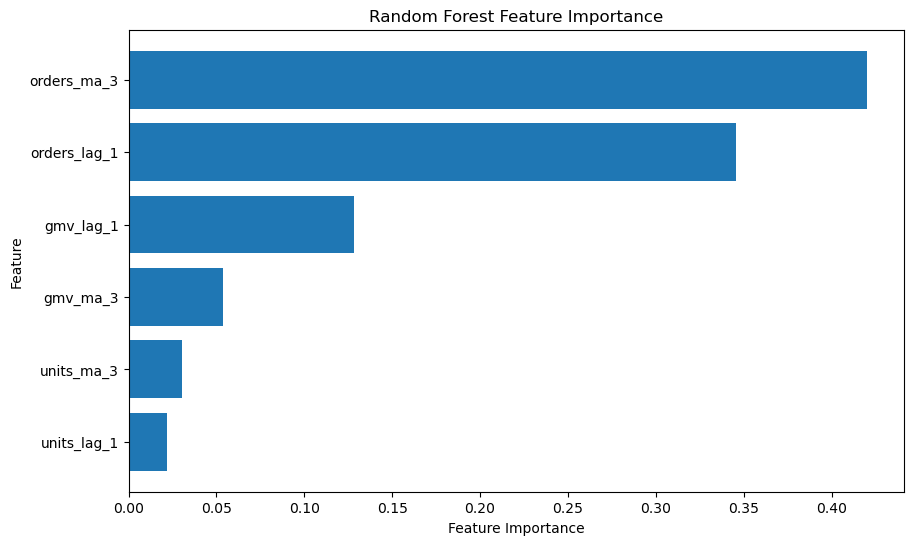

In [76]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis()

plt.show()

In [77]:

rmse_mae_r2 = {
    "lr_rmse_pca": 18258.787710622055,
    "lstm_rmse": 24118.21,
    "xgb_rmse": 33661.77,
    "rf_rmse": 19653.841401109585,
    "lr_mae_pca": 2364.247419429616 ,
    "lstm_mae":3991.56,
    "xgb_mae": 2697.07,
    "rf_mae": 2238.3444317685826,
    "lr_r2_pca": 0.90,
    "lstm_r2": 0.85,
    "xgb_r2":0.70,
    "rf_r2": 0.8969885495953185
}

# Mutate the dictionary values
for key in rmse_mae_r2:
    rmse_mae_r2[key] = round(rmse_mae_r2[key], 2)

print(rmse_mae_r2)

{'lr_rmse_pca': 18258.79, 'lstm_rmse': 24118.21, 'xgb_rmse': 33661.77, 'rf_rmse': 19653.84, 'lr_mae_pca': 2364.25, 'lstm_mae': 3991.56, 'xgb_mae': 2697.07, 'rf_mae': 2238.34, 'lr_r2_pca': 0.9, 'lstm_r2': 0.85, 'xgb_r2': 0.7, 'rf_r2': 0.9}


In [78]:
#VISUALISATION OF MODEL EVALUATION RESULTS

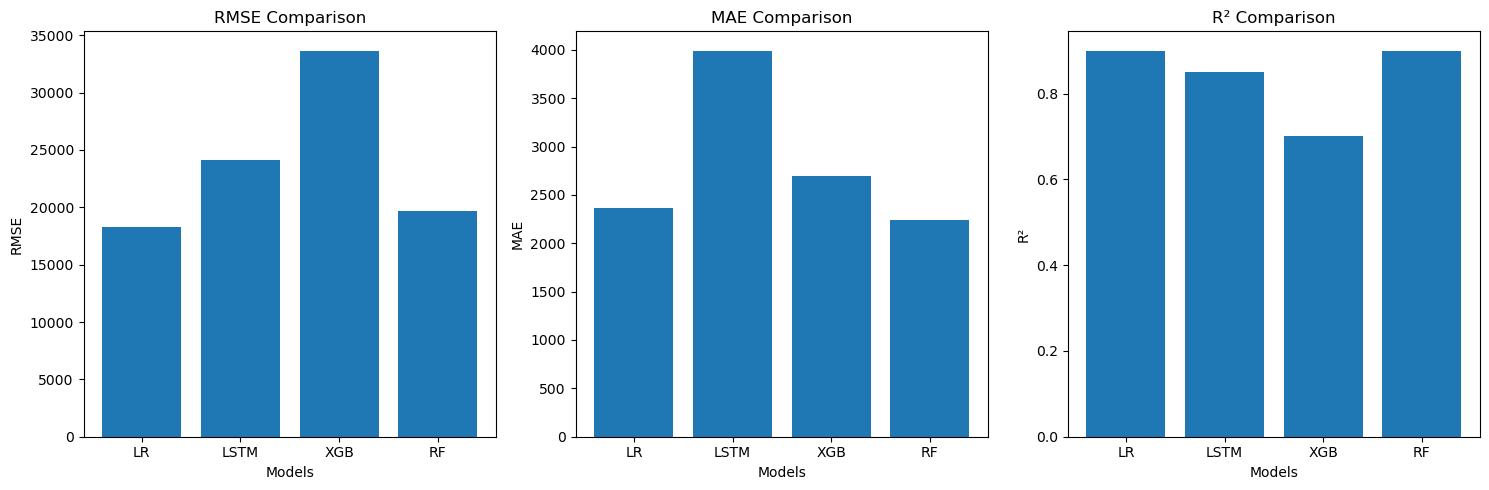

In [79]:
import matplotlib.pyplot as plt

# Model names
models = ['LR', 'LSTM', 'XGB', 'RF']

# Values from mutated dictionary
rmse_values = [
    rmse_mae_r2['lr_rmse_pca'],
    rmse_mae_r2['lstm_rmse'],
    rmse_mae_r2['xgb_rmse'],
    rmse_mae_r2['rf_rmse']
]

mae_values = [
    rmse_mae_r2['lr_mae_pca'],
    rmse_mae_r2['lstm_mae'],
    rmse_mae_r2['xgb_mae'],
    rmse_mae_r2['rf_mae']
]

r2_values = [
    rmse_mae_r2['lr_r2_pca'],
    rmse_mae_r2['lstm_r2'],
    rmse_mae_r2['xgb_r2'],
    rmse_mae_r2['rf_r2']
]

# Create the charts
plt.figure(figsize=(15, 5))

# RMSE
plt.subplot(1, 3, 1)
plt.bar(models, rmse_values)
plt.title('RMSE Comparison')
plt.xlabel('Models')
plt.ylabel('RMSE')

# MAE
plt.subplot(1, 3, 2)
plt.bar(models, mae_values)
plt.title('MAE Comparison')
plt.xlabel('Models')
plt.ylabel('MAE')

# R²
plt.subplot(1, 3, 3)
plt.bar(models, r2_values)
plt.title('R² Comparison')
plt.xlabel('Models')
plt.ylabel('R²')

plt.tight_layout()
plt.show()

In [80]:
# INFERENCE- Random Forest, Linear Regression gives more accurate predictions while explaining variance among the features